# Tsunami Travel Time Calculator

## Dimitrios Mitsotakis

Computes tsunami travel time from a source epicentre using the shallow-water wave speed
$$c = \sqrt{g h}$$
and the **Fast Marching Method** (FMM) to solve the Eikonal equation on the bathymetry grid.

**Required packages:** `numpy`, `xarray`, `matplotlib`, `scikit-fmm`, `cartopy`  
**Bathymetric data set:** `GEBCO_2024.nc`

## 1. Parameters - edit here

In [11]:
import pathlib

# ── Path to GEBCO NetCDF file ──────────────────────────────────────────────
GEBCO_FILE = pathlib.Path("../GEBCO_2024.nc")

# ── Tsunami source (epicentre) ─────────────────────────────────────────────
SOURCE_LON = 159.6   # degrees East  — 2025 Kamchatka earthquake (~M8.0)
SOURCE_LAT =  51.2   # degrees North

# ── Bounding box — full Pacific ────────────────────────────────────────────
LON_MIN, LON_MAX = 120.0, 300.0   # 120°E to 60°W (300°E), covers full Pacific
LAT_MIN, LAT_MAX = -60.0,  70.0

# ── Grid downsampling ──────────────────────────────────────────────────────
DOWNSAMPLE = 10

# ── Travel-time contour interval ──────────────────────────────────────────
CONTOUR_INTERVAL_H = 2   # hours between isolines

# ── Named target locations for arrival-time table ─────────────────────────
TARGETS = {
    # Japan
    "Tokyo (JP)":          (139.7,  35.7),
    "Osaka (JP)":          (135.5,  34.7),
    "Sapporo (JP)":        (141.4,  43.1),
    "Sendai (JP)":         (141.0,  38.3),
    # Australia
    "Sydney (AU)":         (151.2, -33.9),
    "Melbourne (AU)":      (144.9, -37.8),
    "Brisbane (AU)":       (153.0, -27.5),
    "Perth (AU)":          (115.9, -31.9),
    # New Zealand
    "Auckland (NZ)":       (174.8, -36.9),
    "New Plymouth (NZ)":   (174.1, -39.1),
    "Napier (NZ)":         (176.9, -39.5),
    "Wellington (NZ)":     (174.8, -41.3),
    "Christchurch (NZ)":   (172.6, -43.5),
    "Dunedin (NZ)":        (170.5, -45.9),
    # USA
    "Honolulu (HI)":       (360-157.8, 21.3),
    "Hilo (HI)":           (360-155.1, 19.7),
    "Anchorage (AK)":      (360-149.9, 61.2),
    "Seattle (WA)":        (360-122.3, 47.6),
    "Crescent City (CA)":  (360-124.2, 41.7),
    "Los Angeles (CA)":    (360-118.2, 34.1),
    # Latin America
    "Tijuana (MX)":          (360-117.0, 32.5),
    "Manzanillo (MX)":       (360-104.3, 19.1),
    "Guatemala City (GT)":   (360-90.5,  14.6),
    "Lima (PE)":             (360-77.0,  -12.0),
    "Valparaiso (CL)":       (360-71.6,  -33.0),
    "Concepcion (CL)":       (360-73.1,  -36.8),
}

## 2. Load, crop, and Mercator-reproject GEBCO bathymetry

After cropping and downsampling, the bathymetry is reinterpolated row-wise onto
a grid that is **uniform in the isometric latitude** $v = \ln\tan(\pi/4 + \varphi/2)$.
On this Mercator grid the sphere metric becomes conformal,
$ds^{2} = R^{2}\cos^{2}\!\varphi\,(d\lambda^{2} + dv^{2})$,
so the eikonal and amplitude-transport PDEs can be solved with
standard Cartesian stencils (see §4, §5, §8).

In [12]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')

ds = xr.open_dataset(GEBCO_FILE)

print("Dataset variables:", list(ds.data_vars))
print("Dataset dims:", dict(ds.dims))

file_lon_min = float(ds['lon'].values.min())
file_lon_max = float(ds['lon'].values.max())
print(f"File lon range: {file_lon_min:.1f} to {file_lon_max:.1f}")
print(f"File lat range: {float(ds['lat'].values.min()):.1f} to {float(ds['lat'].values.max()):.1f}")

# ── Convert bounding box to file's lon convention for slicing ──────────────
if file_lon_min < 0:
    def to_180(x):
        return x - 360 if x > 180 else x
    lon_min_f = to_180(LON_MIN)
    lon_max_f = to_180(LON_MAX)
else:
    lon_min_f, lon_max_f = LON_MIN, LON_MAX

# Sort lat ascending if needed
if ds['lat'].values[0] > ds['lat'].values[-1]:
    ds = ds.isel(lat=slice(None, None, -1))

# ── Crop ──────────────────────────────────────────────────────────────────
if lon_min_f <= lon_max_f:
    ds_crop = ds.sel(lon=slice(lon_min_f, lon_max_f),
                     lat=slice(LAT_MIN, LAT_MAX))
else:
    part1 = ds.sel(lon=slice(lon_min_f, file_lon_max), lat=slice(LAT_MIN, LAT_MAX))
    part2 = ds.sel(lon=slice(file_lon_min, lon_max_f), lat=slice(LAT_MIN, LAT_MAX))
    part2 = part2.assign_coords(lon=part2['lon'] + 360)
    ds_crop = xr.concat([part1, part2], dim='lon')

# ── Downsample ────────────────────────────────────────────────────────────
ds_crop = ds_crop.isel(lat=slice(None, None, DOWNSAMPLE),
                        lon=slice(None, None, DOWNSAMPLE))

lat_geo = ds_crop['lat'].values.astype(float)        # geographic lat (°)
lon     = ds_crop['lon'].values.astype(float)        # longitude (°), uniform
elev_ll = ds_crop['elevation'].values.astype(float)  # on native lat/lon grid

# ── Mercator reprojection ─────────────────────────────────────────────────
# Isometric latitude v(φ) = ln tan(π/4 + φ/2).  In the (λ, v) coordinates
# the surface metric is conformal,  ds² = R² cos²φ (dλ² + dv²),  so a
# uniform grid in v has an isotropic metric — which is what scikit-fmm and
# the §8 sweep require.  Longitude is already uniform, so we only need a
# 1-D row-wise reinterpolation of the bathymetry in latitude.
def isometric(phi_deg):
    return np.log(np.tan(np.pi/4 + np.radians(phi_deg)/2))

v_src  = isometric(lat_geo)
v_min, v_max = v_src[0], v_src[-1]

# Pick Ny_merc so the equatorial row resolution matches the original dlat.
dlat_rad_eq = np.radians(abs(lat_geo[1] - lat_geo[0]))
Ny_merc = int(round((v_max - v_min) / dlat_rad_eq)) + 1
v_grid  = np.linspace(v_min, v_max, Ny_merc)
phi_grid_rad = 2.0 * np.arctan(np.exp(v_grid)) - np.pi / 2
lat = np.degrees(phi_grid_rad)                       # geographic lat on Mercator grid

elev = np.empty((Ny_merc, lon.size), dtype=float)
for k in range(lon.size):
    elev[:, k] = np.interp(v_grid, v_src, elev_ll[:, k])

print(f"Native lat/lon grid (1/{DOWNSAMPLE}): {elev_ll.shape}")
print(f"Mercator grid:                    {elev.shape}  "
      f"lat [{lat[0]:.1f}, {lat[-1]:.1f}]  "
      f"lon [{lon[0]:.1f}, {lon[-1]:.1f}]")

Dataset variables: ['crs', 'elevation']
Dataset dims: {'lat': 43200, 'lon': 86400}
File lon range: -180.0 to 180.0
File lat range: -90.0 to 90.0
Native lat/lon grid (1/10): (3120, 4320)
Mercator grid:                    (4195, 4320)  lat [-60.0, 70.0]  lon [120.0, 300.0]


## 3. Compute wave-speed grid

The shallow-water phase speed is $c = \sqrt{g h}$ where $h$ is water depth.
Land cells receive a small but non-zero speed so the FMM stays numerically well-posed;
their travel times are masked in the final plot.

In [13]:
g = 9.81   # m/s²

depth = np.where(elev < 0, -elev, 0.0)    # ocean depth ≥ 0 m
speed = np.sqrt(g * depth)                 # m/s  (0 on land)
speed = np.where(speed < 1.0, 1.0, speed)  # floor at 1 m/s to keep FMM well-posed

ocean_mask = elev < 0   # True = ocean cell

print(f"Max wave speed : {speed.max():.0f} m/s  ({speed.max()*3.6:.0f} km/h)")
print(f"Median (ocean) : {np.median(speed[ocean_mask]):.0f} m/s")

Max wave speed : 324 m/s  (1168 km/h)
Median (ocean) : 202 m/s


## 4. Grid spacing on the Mercator $(X, Y)$ grid

With $X = R\lambda$, $Y = R v$ the grid is uniform with $dX = dY$ at the equator.
The sphere metric $ds^{2}=\cos^{2}\!\varphi\,(dX^{2}+dY^{2})$ is absorbed into
$c_{\text{eff}} = c/\cos\varphi$ for the eikonal in §5 and cancels identically
in the §8 transport PDE, so both solvers work on $(X,Y)$ with Cartesian stencils.

In [14]:
R = 6_371_000.0   # Earth radius, metres

# ── Mercator uniform spacings ────────────────────────────────────────────
# In coords X = R·λ,  Y = R·v the grid is uniform with dX = dY (equatorial m).
# The sphere metric ds² = cos²φ (dX² + dY²) is absorbed into c_eff = c/cosφ
# for the eikonal in §5, and cancels identically in the §8 transport PDE.
dlon_rad = np.radians(abs(lon[1] - lon[0]))
dv       = v_grid[1] - v_grid[0]

dX = R * dlon_rad
dY = R * dv

cos_phi = np.cos(np.radians(lat))[:, None]            # (Ny, 1), for broadcasting

print(f"dX = {dX/1000:.2f} km   dY = {dY/1000:.2f} km  (equatorial, uniform in Mercator)")
print(f"Physical row spacing (R·cosφ·dv):  "
      f"{dY*cos_phi[ 0,0]/1000:.2f} km at lat={lat[ 0]:.0f}°,  "
      f"{dY*cos_phi[-1,0]/1000:.2f} km at lat={lat[-1]:.0f}°")

dX = 4.63 km   dY = 4.63 km  (equatorial, uniform in Mercator)
Physical row spacing (R·cosφ·dv):  2.32 km at lat=-60°,  1.59 km at lat=70°


## 5. Fast Marching Method — solve the Eikonal equation on the sphere

On the sphere, $|\nabla_{\!S} T| = 1/c$ becomes
$(\partial_X T)^{2} + (\partial_Y T)^{2} = \cos^{2}\!\varphi / c^{2} = 1/c_{\text{eff}}^{2}$
with $c_{\text{eff}} = c/\cos\varphi$, so one call to
`skfmm.travel_time(phi, c_eff, dx=(dY, dX))` on the uniform Mercator grid
returns physical travel time in seconds.

In [15]:
import skfmm

# Use a masked phi so FMM never propagates through land cells
phi = np.ma.MaskedArray(np.ones_like(speed), mask=~ocean_mask)
iy  = np.argmin(np.abs(lat - SOURCE_LAT))
ix  = np.argmin(np.abs(lon - SOURCE_LON))
phi[iy, ix] = -1.0

print(f"Source snapped to grid: lon = {lon[ix]:.2f}°,  lat = {lat[iy]:.2f}°")
print("Running FMM (this may take a moment for large grids)...")

# ── Eikonal on the sphere in Mercator coords (X, Y) ──────────────────────
# |∇_S T|² = 1/c²   ⇒   (∂_X T)² + (∂_Y T)² = cos²φ / c² = 1 / c_eff²
c_eff = speed / cos_phi
travel_time_s   = skfmm.travel_time(phi, c_eff, dx=(dY, dX))   # seconds
travel_time_min = travel_time_s / 60.0

travel_time_min = np.ma.masked_where(~ocean_mask, travel_time_min)

print(f"Done.  Max ocean travel time: {travel_time_min.max():.0f} min  "
      f"({travel_time_min.max()/60:.1f} h)")

# ── Self-consistency:  |∇T|² · c_eff²  should be ≈ 1 on the interior ────
Ts  = travel_time_s.filled(np.nan)
gTx = np.zeros_like(Ts); gTy = np.zeros_like(Ts)
gTx[:, 1:-1] = (Ts[:, 2:] - Ts[:, :-2]) / (2 * dX)
gTy[1:-1, :] = (Ts[2:, :] - Ts[:-2, :]) / (2 * dY)
check = (gTx**2 + gTy**2) * c_eff**2
check_interior = check[ocean_mask & np.isfinite(check)]
print(f"Eikonal self-check  |∇T|²·c_eff²  —  mean: {check_interior.mean():.3f}, "
      f"std: {check_interior.std():.3f}  (expect ≈ 1)")

Source snapped to grid: lon = 159.59°,  lat = 51.21°
Running FMM (this may take a moment for large grids)...
Done.  Max ocean travel time: 2443 min  (40.7 h)
Eikonal self-check  |∇T|²·c_eff²  —  mean: 1.002, std: 0.398  (expect ≈ 1)


## 6. Quick plot

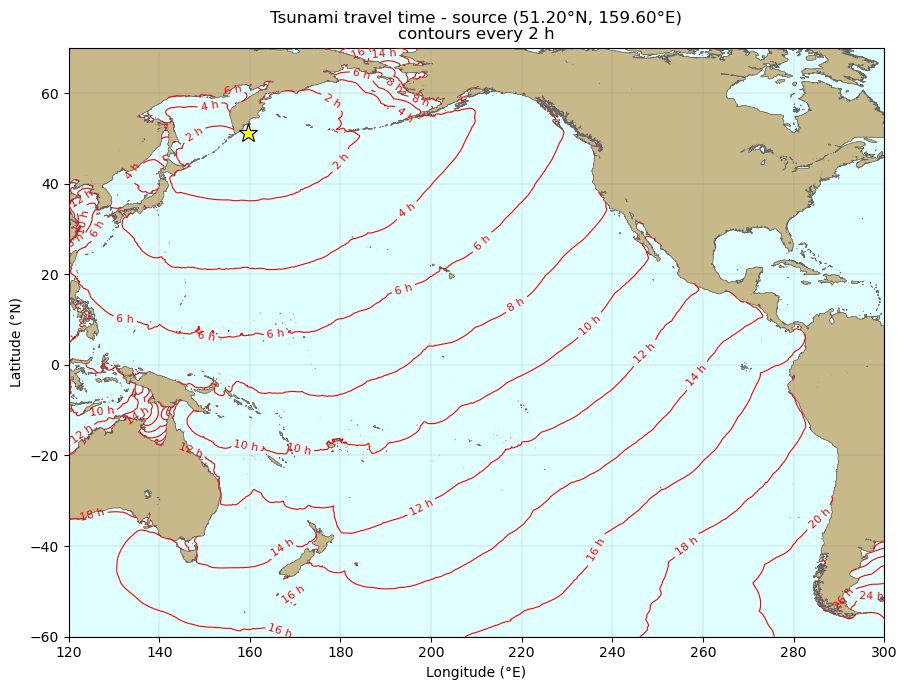

Figure saved into tsunami_travel_time_simple.png


In [16]:
# ── Quick plot: travel-time contours + land, no bathymetry ────────────────
LON2D, LAT2D = np.meshgrid(lon, lat)
travel_time_h = travel_time_min / 60.0
max_h  = float(travel_time_h.max())
levels = np.arange(0, max_h + CONTOUR_INTERVAL_H, CONTOUR_INTERVAL_H)

fig, ax = plt.subplots(figsize=(12, 7))
ax.set_xlim(LON_MIN, LON_MAX)
ax.set_ylim(LAT_MIN, LAT_MAX)
ax.set_facecolor('lightcyan')
ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°N)")
ax.set_aspect('equal')

# Land fill and coastline from GEBCO elevation
land_elev = np.ma.masked_where(elev < 0, elev)
ax.contourf(LON2D, LAT2D, land_elev, levels=1, colors=['#c8b98a'], zorder=1)
ax.contour(LON2D, LAT2D, elev, levels=[0], colors=['#666666'], linewidths=0.5, zorder=2)

# Travel-time isolines
cs = ax.contour(LON2D, LAT2D, travel_time_h, levels=levels,
                colors='red', linewidths=0.8, zorder=3)
ax.clabel(cs, fmt=lambda v: f"{v:.0f} h", fontsize=8, inline=True)

ax.plot(SOURCE_LON, SOURCE_LAT, marker='*', color='yellow', markersize=14,
        markeredgecolor='black', markeredgewidth=0.8, zorder=5, linestyle='none')

ax.grid(linewidth=0.3, color='grey', alpha=0.5)
ax.set_title(
    f"Tsunami travel time - source ({SOURCE_LAT:.2f}°N, {SOURCE_LON:.2f}°E)\n"
    f"contours every {CONTOUR_INTERVAL_H} h", fontsize=12
)
plt.tight_layout()
plt.savefig("tsunami_travel_time_simple.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved into tsunami_travel_time_simple.png")

## 7. Full plot

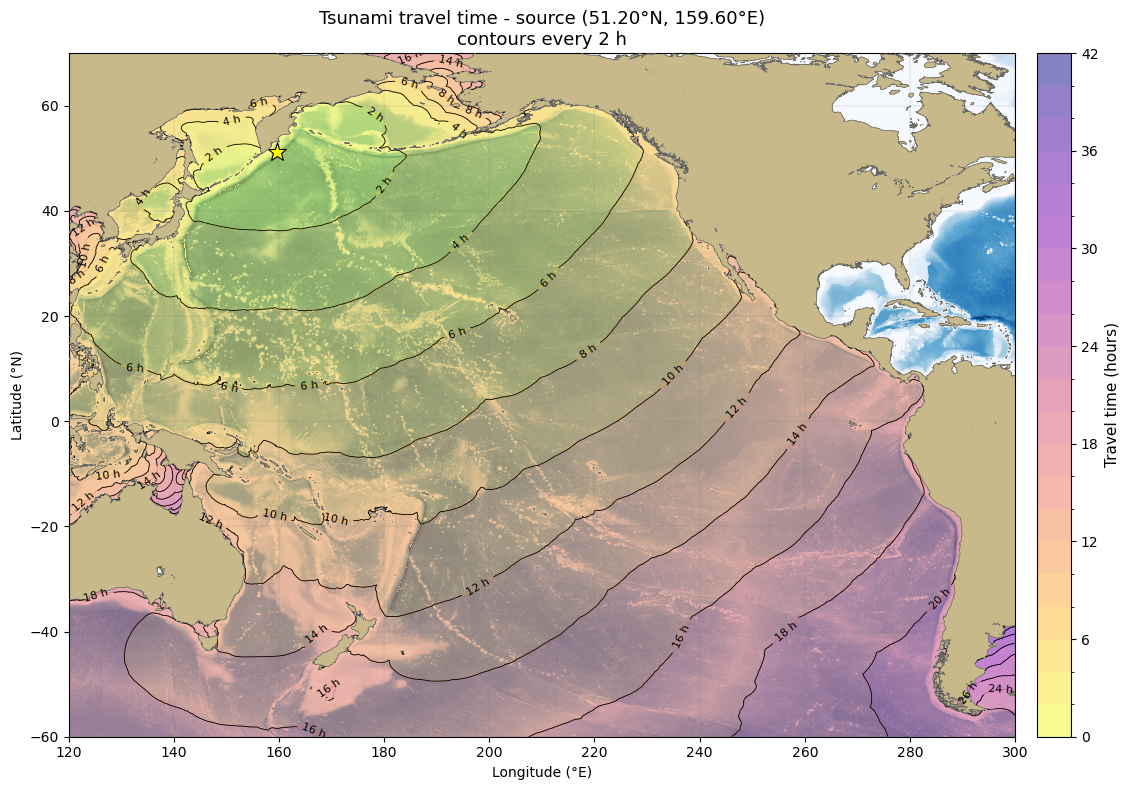

Figure saved into tsunami_travel_time.png


In [17]:
# ── Full plot: travel-time bands over bathymetry ──────────────────────────
LON2D, LAT2D = np.meshgrid(lon, lat)
travel_time_h = travel_time_min / 60.0
max_h  = float(travel_time_h.max())
levels = np.arange(0, max_h + CONTOUR_INTERVAL_H, CONTOUR_INTERVAL_H)

bathy_levels = np.linspace(-8000, 0, 81)
land_color   = "#c8b98a"
tt_cmap      = plt.cm.plasma_r
norm         = mcolors.BoundaryNorm(levels, ncolors=tt_cmap.N)

fig, ax = plt.subplots(figsize=(12, 8))
ax.set_xlim(LON_MIN, LON_MAX)
ax.set_ylim(LAT_MIN, LAT_MAX)
ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°N)")
ax.set_aspect('equal')

# Bathymetry background
ocean_elev = np.ma.masked_where(elev >= 0, elev)
ax.contourf(LON2D, LAT2D, ocean_elev, levels=bathy_levels, cmap='Blues_r', zorder=0)

# Travel-time filled bands
cf = ax.contourf(LON2D, LAT2D, travel_time_h, levels=levels,
                 cmap=tt_cmap, norm=norm, alpha=0.5, zorder=1)

# Land on top
land_elev = np.ma.masked_where(elev < 0, elev)
ax.contourf(LON2D, LAT2D, land_elev, levels=1, colors=[land_color], zorder=2)
ax.contour(LON2D, LAT2D, elev, levels=[0], colors=['#666666'], linewidths=0.5, zorder=3)

# Travel-time isolines
cs = ax.contour(LON2D, LAT2D, travel_time_h, levels=levels,
                colors='k', linewidths=0.6, zorder=4)
ax.clabel(cs, fmt=lambda v: f"{v:.0f} h", fontsize=8, inline=True)

# Source marker
ax.plot(SOURCE_LON, SOURCE_LAT, marker='*', color='yellow', markersize=14,
        markeredgecolor='black', markeredgewidth=0.8, zorder=6, linestyle='none')
# ax.annotate("Source", xy=(SOURCE_LON, SOURCE_LAT),
#             xytext=(SOURCE_LON + 1, SOURCE_LAT + 1),
#             fontsize=9, color='yellow', fontweight='bold',
#             arrowprops=dict(arrowstyle='->', color='yellow', lw=0.8))

# Colourbar
cbar = fig.colorbar(cf, ax=ax, orientation='vertical', pad=0.02, fraction=0.04)
cbar.set_label("Travel time (hours)", fontsize=11)

ax.grid(linewidth=0.3, color='grey', alpha=0.5)
ax.set_title(
    f"Tsunami travel time - source ({SOURCE_LAT:.2f}°N, {SOURCE_LON:.2f}°E)\n"
    f"contours every {CONTOUR_INTERVAL_H} h", fontsize=13
)
plt.tight_layout()
plt.savefig("tsunami_travel_time.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved into tsunami_travel_time.png")

## 7. Arrival times at named locations

In [18]:
print(f"{'Location':<28} {'Travel time':>22}")
print("-" * 52)

# Pre-compute indices of all reachable (unmasked) ocean cells
reachable = ~np.ma.getmaskarray(travel_time_min) & ocean_mask
reach_iy, reach_ix = np.where(reachable)

for name, (tlon, tlat) in TARGETS.items():
    if not (LON_MIN <= tlon <= LON_MAX and LAT_MIN <= tlat <= LAT_MAX):
        print(f"{name:<28} {'outside domain':>22}")
        continue

    ix_t = np.argmin(np.abs(lon - tlon))
    iy_t = np.argmin(np.abs(lat - tlat))

    # Find nearest reachable ocean cell (handles coarse grids closing passages)
    if not reachable[iy_t, ix_t]:
        dist2 = (reach_iy - iy_t)**2 + (reach_ix - ix_t)**2
        nearest = np.argmin(dist2)
        iy_t, ix_t = reach_iy[nearest], reach_ix[nearest]

    tt = travel_time_min[iy_t, ix_t]

    if np.ma.is_masked(tt):
        label = "not reached"
    else:
        h = int(tt) // 60
        m = int(tt) % 60
        label = f"{h} h {m:02d} min  ({tt:.0f} min total)"

    print(f"{name:<28} {label:>22}")

Location                                Travel time
----------------------------------------------------
Tokyo (JP)                   5 h 11 min  (312 min total)
Osaka (JP)                   5 h 31 min  (332 min total)
Sapporo (JP)                 4 h 33 min  (274 min total)
Sendai (JP)                  3 h 14 min  (195 min total)
Sydney (AU)                  12 h 54 min  (775 min total)
Melbourne (AU)               19 h 03 min  (1144 min total)
Brisbane (AU)                13 h 11 min  (792 min total)
Perth (AU)                           outside domain
Auckland (NZ)                14 h 18 min  (859 min total)
New Plymouth (NZ)            14 h 24 min  (864 min total)
Napier (NZ)                  13 h 21 min  (802 min total)
Wellington (NZ)              13 h 30 min  (811 min total)
Christchurch (NZ)            14 h 32 min  (873 min total)
Dunedin (NZ)                 15 h 11 min  (911 min total)
Honolulu (HI)                6 h 07 min  (368 min total)
Hilo (HI)                    6 h 33

## 8. Geometric-optics amplitude $A_0$

On the sphere, the transport equation reads
$$\nabla_{\!S}\!\cdot\!\bigl(c^2 A_0^2\,\nabla_{\!S} T\bigr) = 0.$$
Written out in Mercator coordinates $(X,Y)$ the $\cos^{2}\!\varphi$ metric
factors cancel and the equation takes the exact Cartesian form
$$\partial_X(c^2 A_0^2\,\partial_X T) \;+\; \partial_Y(c^2 A_0^2\,\partial_Y T) \;=\; 0.$$
Setting $u = A_0^2$ and expanding,
$$\nabla T \cdot \nabla u \;=\; -\,\alpha\,u,\qquad
\alpha \;=\; \frac{\nabla\!\cdot(c^2\nabla T)}{c^2}$$
— a first-order transport equation along rays, solved by an **upwind sweep
in order of increasing $T$**. Near the source we seed a small disk with
Green's law for cylindrical spreading, $A_0^2 \propto 1/(c\,r)$, using the
great-circle distance $r$.

In [19]:
# ── Gradients of T and divergence of c² ∇T on the Mercator (X, Y) grid ──
# In Mercator coords the sphere PDE ∇_S·(c² A_0² ∇_S T) = 0 becomes, exactly,
#     ∂_X(c² A_0² ∂_X T) + ∂_Y(c² A_0² ∂_Y T) = 0
# with the *original* c (the cos²φ metric factors cancel).  So the sweep is
# purely Cartesian on (X, Y) with spacings dX, dY from §4.

T_s = np.asarray(travel_time_s.filled(np.nan), dtype=float)
c2  = speed**2

Tx = np.zeros_like(T_s)
Ty = np.zeros_like(T_s)
Tx[:, 1:-1] = (T_s[:, 2:] - T_s[:, :-2]) / (2 * dX)
Ty[1:-1, :] = (T_s[2:, :] - T_s[:-2, :]) / (2 * dY)
Tx[:,  0] = (T_s[:,  1] - T_s[:,  0]) / dX
Tx[:, -1] = (T_s[:, -1] - T_s[:, -2]) / dX
Ty[ 0, :] = (T_s[ 1, :] - T_s[ 0, :]) / dY
Ty[-1, :] = (T_s[-1, :] - T_s[-2, :]) / dY

Fx, Fy = c2 * Tx, c2 * Ty
dFx = np.zeros_like(T_s); dFy = np.zeros_like(T_s)
dFx[:, 1:-1] = (Fx[:, 2:] - Fx[:, :-2]) / (2 * dX)
dFy[1:-1, :] = (Fy[2:, :] - Fy[:-2, :]) / (2 * dY)
alpha = (dFx + dFy) / c2

for arr in (Tx, Ty, alpha):
    arr[~np.isfinite(arr)] = 0.0

# ── Seed disk: Green's law  u = 1/(c·r)  with r = great-circle distance ──
dlam = np.radians(LON2D - lon[ix])
dphi = np.radians(LAT2D - lat[iy])
hav  = (np.sin(dphi/2)**2
        + np.cos(np.radians(lat[iy])) * np.cos(np.radians(LAT2D))
        * np.sin(dlam/2)**2)
R_dist = 2.0 * R * np.arcsin(np.sqrt(np.clip(hav, 0.0, 1.0)))

r_floor = 0.5 * max(dX, dY)
r_seed  = 3.0 * max(dX, dY)

valid = ocean_mask & np.isfinite(T_s)
u     = np.full_like(T_s, np.nan)
seed  = valid & (R_dist < r_seed)
u[seed] = 1.0 / (speed[seed] * np.maximum(R_dist[seed], r_floor))

# ── Upwind sweep ordered by increasing T ─────────────────────────────────
ny_, nx_ = T_s.shape
Tkey  = np.where(valid, T_s, np.inf)
order = np.argsort(Tkey, axis=None, kind='stable')

u_f     = u.reshape(-1)
Tx_f    = Tx.reshape(-1)
Ty_f    = Ty.reshape(-1)
alpha_f = alpha.reshape(-1)
valid_f = valid.reshape(-1)

inv_dX, inv_dY = 1.0 / dX, 1.0 / dY
n_valid = int(valid.sum())
print(f"Sweeping {n_valid:,} ocean cells (this takes ~1 min on the full grid)...")

n_done = 0
for idx in order:
    if not valid_f[idx]:
        break
    if not np.isnan(u_f[idx]):
        continue
    i = idx // nx_
    j = idx - i * nx_

    txi, tyi, ai = Tx_f[idx], Ty_f[idx], alpha_f[idx]
    cx = 0.0; cy = 0.0; rhs = 0.0

    if txi > 0.0 and j > 0:
        uu = u_f[idx - 1]
        if uu == uu:                 # NaN-safe check
            cx  = txi * inv_dX
            rhs += cx * uu
    elif txi < 0.0 and j < nx_ - 1:
        uu = u_f[idx + 1]
        if uu == uu:
            cx  = -txi * inv_dX
            rhs += cx * uu

    if tyi > 0.0 and i > 0:
        uu = u_f[idx - nx_]
        if uu == uu:
            cy  = tyi * inv_dY
            rhs += cy * uu
    elif tyi < 0.0 and i < ny_ - 1:
        uu = u_f[idx + nx_]
        if uu == uu:
            cy  = -tyi * inv_dY
            rhs += cy * uu

    denom = cx + cy + ai
    u_f[idx] = rhs / denom if (cx + cy) > 0.0 and denom > 0.0 else 0.0
    n_done += 1

A0_sq = np.where(valid, np.maximum(u, 0.0), np.nan)
A0    = np.sqrt(A0_sq)
A0    = np.ma.masked_where(~valid, A0)

print(f"Done. A_0 on ocean — min: {A0.min():.2e}, "
      f"median: {np.ma.median(A0):.2e}, max: {A0.max():.2e}")

Sweeping 12,139,278 ocean cells (this takes ~1 min on the full grid)...
Done. A_0 on ocean — min: 0.00e+00, median: 3.14e-08, max: 2.51e+08


## 9. Plot the amplitude field $A_0$

Amplitudes span many orders of magnitude (cylindrical spreading plus
refraction), so we display $\log_{10} A_0$ normalised by its value on the
seed disk.

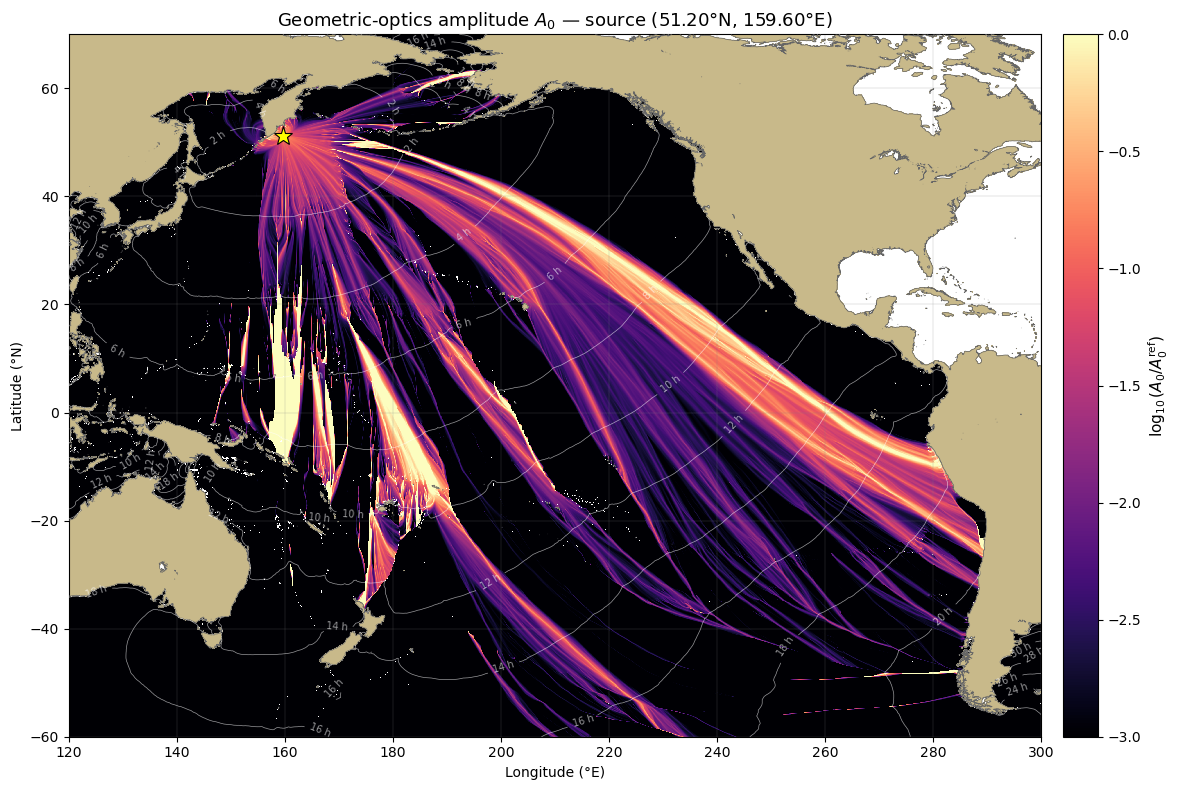

Figure saved into tsunami_amplitude_A0.png


In [20]:
# ── Plot log10(A_0) with travel-time contours overlaid ───────────────────
A0_ref = float(A0[seed].max())   # reference amplitude on the seed ring
logA   = np.ma.log10(np.ma.masked_less_equal(A0 / A0_ref, 0.0))

fig, ax = plt.subplots(figsize=(12, 8))
ax.set_xlim(LON_MIN, LON_MAX)
ax.set_ylim(LAT_MIN, LAT_MAX)
ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°N)")
ax.set_aspect('equal')

vmin, vmax = -3.0, 0.0   # clip at 3 orders of magnitude below source
pcm = ax.pcolormesh(LON2D, LAT2D, logA, cmap='magma',
                    vmin=vmin, vmax=vmax, shading='auto', zorder=1)

# Land
land_elev = np.ma.masked_where(elev < 0, elev)
ax.contourf(LON2D, LAT2D, land_elev, levels=1, colors=['#c8b98a'], zorder=2)
ax.contour(LON2D, LAT2D, elev, levels=[0], colors=['#666666'],
           linewidths=0.5, zorder=3)

# Travel-time contours for reference
cs = ax.contour(LON2D, LAT2D, travel_time_h, levels=levels,
                colors='white', linewidths=0.5, alpha=0.6, zorder=4)
ax.clabel(cs, fmt=lambda v: f"{v:.0f} h", fontsize=7, inline=True)

ax.plot(SOURCE_LON, SOURCE_LAT, marker='*', color='yellow', markersize=14,
        markeredgecolor='black', markeredgewidth=0.8, zorder=6, linestyle='none')

cbar = fig.colorbar(pcm, ax=ax, orientation='vertical', pad=0.02, fraction=0.04)
cbar.set_label(r"$\log_{10}(A_0 / A_0^{\mathrm{ref}})$", fontsize=11)

ax.grid(linewidth=0.3, color='grey', alpha=0.5)
ax.set_title(
    f"Geometric-optics amplitude $A_0$ — source "
    f"({SOURCE_LAT:.2f}°N, {SOURCE_LON:.2f}°E)",
    fontsize=13
)
plt.tight_layout()
plt.savefig("tsunami_amplitude_A0.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved into tsunami_amplitude_A0.png")